# Imports

In [1]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import torch
import torchvision
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Replacing backbone and initialization

In [3]:
model_file = "/kaggle/working/yolo11-mobilenet.yaml"


with open(model_file, "w") as f:
    f.write("""
nc: 80 # number of classes
scales:
  # [depth, width, max_channels]
  n: [0.50, 0.25, 1024]

backbone:
  - [-1, 1, TorchVision, [768, mobilenet_v3_small, DEFAULT, True, 2, True]]  # 0

head:
  # Extract features from MobileNetV3 Small
  - [0, 1, Index, [24, 3]]          # 1: P3 raw (stride 8)
  - [0, 1, Index, [48, 9]]          # 2: P4 raw (stride 16)
  - [0, 1, Index, [576, 13]]        # 3: P5 raw (stride 32)

  # Project to full YOLOv11 channel sizes (scaled automatically by width=0.25)
  - [1, 1, Conv, [256, 1, 1]]       # 4: P3 → 256
  - [2, 1, Conv, [512, 1, 1]]       # 5: P4 → 512
  - [3, 1, Conv, [1024, 1, 1]]      # 6: P5 → 1024

  # FPN: P5 → P4
  - [6, 1, nn.Upsample, [None, 2, "nearest"]]   # 7
  - [[7, 5], 1, Concat, [1]]                    # 8
  - [-1, 2, C3k2, [512, False]]                 # 9

  # FPN: P4 → P3
  - [9, 1, nn.Upsample, [None, 2, "nearest"]]   # 10
  - [[10, 4], 1, Concat, [1]]                   # 11
  - [-1, 2, C3k2, [256, False]]                 # 12 (P3/8-small)

  # PAN: P3 → P4
  - [12, 1, Conv, [256, 3, 2]]                  # 13
  - [[13, 9], 1, Concat, [1]]                   # 14
  - [-1, 2, C3k2, [512, False]]                 # 15 (P4/16-medium)

  # PAN: P4 → P5
  - [15, 1, Conv, [512, 3, 2]]                  # 16
  - [[16, 6], 1, Concat, [1]]                   # 17
  - [-1, 2, C3k2, [1024, True]]                 # 18 (P5/32-large)

  # Final detection layers
  - [[12, 15, 18], 1, Detect, [nc]]             # 19


  
# backbone layers:
# 0 torch.Size([1, 3, 640, 640])
# 1 torch.Size([1, 16, 320, 320])
# 2 torch.Size([1, 16, 160, 160])
# 3 torch.Size([1, 24, 80, 80])
# 4 torch.Size([1, 24, 80, 80])
# 5 torch.Size([1, 40, 40, 40])
# 6 torch.Size([1, 40, 40, 40])
# 7 torch.Size([1, 40, 40, 40])
# 8 torch.Size([1, 48, 40, 40])
# 9 torch.Size([1, 48, 40, 40])
# 10 torch.Size([1, 96, 20, 20])
# 11 torch.Size([1, 96, 20, 20])
# 12 torch.Size([1, 96, 20, 20])
# 13 torch.Size([1, 576, 20, 20])
""")


model = YOLO(model_file, task="detect")

WARNING ⚠️ no model scale passed. Assuming scale='n'.


# Data

In [4]:
data_file = "/kaggle/working/data.yaml"


with open(data_file, "w") as f:
    f.write("""train: /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/train
val: /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/val
test: /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/test
nc: 1
names: ["human"]""")

# Fine-tuning

In [5]:
model.train(
    data=data_file,
    epochs=200,
    patience=10,
    imgsz=640,
    batch=16,
    name="yolo11_mobilenetnet_epoch"
)

!zip -r yolo11_mobilenet.zip /kaggle/working

Ultralytics 8.3.101 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/yolo11-mobilenet.yaml, data=/kaggle/working/data.yaml, epochs=200, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolo11_mobilenetnet_epoch, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, sa

100%|██████████| 755k/755k [00:00<00:00, 101MB/s]


Overriding model.yaml nc=80 with nc=1
WARNING ⚠️ no model scale passed. Assuming scale='n'.

                   from  n    params  module                                       arguments                     
  0                  -1  1    927008  ultralytics.nn.modules.block.TorchVision     ['mobilenet_v3_small', 'DEFAULT', True, 2, True]
  1                   0  1         0  ultralytics.nn.modules.conv.Index            [3]                           
  2                   0  1         0  ultralytics.nn.modules.conv.Index            [9]                           
  3                   0  1         0  ultralytics.nn.modules.conv.Index            [13]                          
  4                   1  1      1664  ultralytics.nn.modules.conv.Conv             [24, 64, 1, 1]                
  5                   2  1      6400  ultralytics.nn.modules.conv.Conv             [48, 128, 1, 1]               
  6                   3  1    147968  ultralytics.nn.modules.conv.Conv             [576, 25

100%|██████████| 5.35M/5.35M [00:00<00:00, 377MB/s]


AMP: checks passed ✅


...

                   all        253       1267      0.755      0.551      0.607      0.245
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 123, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

133 epochs completed in 2.208 hours.
Optimizer stripped from runs/detect/yolo11_mobilenetnet_epoch/weights/last.pt, 4.9MB
Optimizer stripped from runs/detect/yolo11_mobilenetnet_epoch/weights/best.pt, 4.9MB

Validating runs/detect/yolo11_mobilenetnet_epoch/weights/best.pt...
Ultralytics 8.3.101 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11-mobilenet summary: 197 layers, 2,299,555 parameters, 0 gradients, 4.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:04<00:00,  1.66it/s]


                   all        253       1267      0.742      0.543      0.602      0.249


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs/detect/yolo11_mobilenetnet_epoch
  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/data.yaml (deflated 56%)
  adding: kaggle/working/yolo11n.pt (deflated 11%)
  adding: kaggle/working/yolo11-mobilenet.yaml (deflated 63%)
  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/ (stored 0%)
  adding: kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/val_batch1_labels.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/results.png (deflated 9%)
  adding: kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/val_batch2_pred.jpg (deflated 9%)
  adding: kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/train_batch2.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/confusion_matrix_normalized.png (deflated 38%)
  ad

# Testing

In [6]:
def show_img_with_boxes(res):
    img = res[0].plot()
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()



image 1/1 /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/test/10209.jpg: 384x640 8 humans, 47.8ms
Speed: 2.4ms preprocess, 47.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


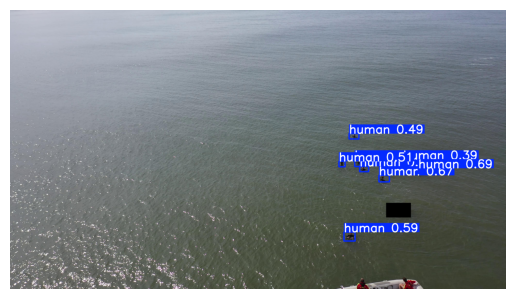

Ultralytics 8.3.101 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11-mobilenet summary: 197 layers, 2,299,555 parameters, 0 gradients, 4.7 GFLOPs


val: Scanning /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/labels/test... 253 images, 0 backgrounds, 0 corrupt: 100%|██████████| 253/253 [00:02<00:00, 119.94it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/labels is not writeable, cache not saved.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:06<00:00,  2.56it/s]


                   all        253       1363      0.774      0.632       0.66      0.266


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.8ms preprocess, 3.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cee1816cd60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.040

In [8]:
model = YOLO("/kaggle/working/runs/detect/yolo11_mobilenetnet_epoch/weights/best.pt")

img = "/kaggle/input/seadronessee-yolo-2029/seaDronesSee_yolo/images/test/10209.jpg"

results = model(img)
show_img_with_boxes(results)

metrics = model.val(
    data=data_file,
    split="test"
)

print(metrics)